In [ ]:
# ── CELL 1 : Installs & Imports ─────────────────────────────────────────────
!pip install -q tensorflow scikit-learn matplotlib seaborn

import os, json, pickle, random, urllib.request, tarfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Dense, Dropout,
    Conv1D, GlobalMaxPooling1D, Concatenate,
    SpatialDropout1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TF version : 2.20.0
GPU        : []


In [ ]:
# ── CELL 2 : Mount Drive & Folders ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ICT4442_Project'

DRIVE = {
    'shared'  : f'{BASE}/shared',        # tokenizer lives here (saved by MLP)
    'weights' : f'{BASE}/CNN/weights',
    'history' : f'{BASE}/CNN/history',
    'results' : f'{BASE}/CNN/results',
}
for d in DRIVE.values():
    os.makedirs(d, exist_ok=True)

LOCAL = {
    'data'  : '/content/data',
    'plots' : '/content/plots/CNN',
}
for d in LOCAL.values():
    os.makedirs(d, exist_ok=True)

# ── Shared constants — must match MLP exactly ────────────────────────────────
VOCAB_SIZE = 20000
MAX_LEN    = 512      # updated from 256 based on MLP length analysis
EMBED_DIM  = 128

print(f"VOCAB_SIZE={VOCAB_SIZE}  MAX_LEN={MAX_LEN}  EMBED_DIM={EMBED_DIM}")
print("Folders ready.")

Mounted at /content/drive
VOCAB_SIZE=20000  MAX_LEN=512  EMBED_DIM=128
Folders ready.


In [ ]:
# ── CELL 3 : Dataset + Tokenizer + Sequences ────────────────────────────────
DATA_PATH = '/content/data/aclImdb'

if not os.path.exists(DATA_PATH):
    print("Downloading IMDb dataset (~84 MB) to local /content ...")
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    urllib.request.urlretrieve(url, '/content/data/aclImdb_v1.tar.gz')
    print("Extracting...")
    with tarfile.open('/content/data/aclImdb_v1.tar.gz', 'r:gz') as t:
        t.extractall('/content/data/')
    os.remove('/content/data/aclImdb_v1.tar.gz')
    print("Done.")
else:
    print("Dataset already local — skipping download.")

def load_split(split_dir):
    texts, labels = [], []
    for label_idx, sentiment in enumerate(['neg', 'pos']):
        folder = os.path.join(split_dir, sentiment)
        for fname in sorted(os.listdir(folder)):
            if fname.endswith('.txt'):
                with open(os.path.join(folder, fname),
                          encoding='utf-8') as f:
                    texts.append(f.read())
                labels.append(label_idx)
    return texts, labels

print("Loading splits...")
train_texts_full, train_labels_full = load_split(f'{DATA_PATH}/train')
test_texts,       test_labels_raw   = load_split(f'{DATA_PATH}/test')

# Same stratified split as MLP — SEED and test_size must not change
train_texts, val_texts, train_labels_raw, val_labels_raw = train_test_split(
    train_texts_full, train_labels_full,
    test_size=5000, random_state=SEED, stratify=train_labels_full
)

train_labels = np.array(train_labels_raw)
val_labels   = np.array(val_labels_raw)
test_labels  = np.array(test_labels_raw)

print(f"Train : {len(train_texts):,}  Val : {len(val_texts):,}  "
      f"Test : {len(test_texts):,}")

# Load tokenizer from Drive — fitted only on training data by MLP notebook
TOKENIZER_PATH = f"{DRIVE['shared']}/tokenizer.pkl"
print(f"\nLoading tokenizer from Drive: {TOKENIZER_PATH}")
with open(TOKENIZER_PATH, 'rb') as f:
    tokenizer = pickle.load(f)
print("Tokenizer loaded.")

# Build padded sequences locally — fast, no Drive space used
print("Building sequences (MAX_LEN=512)...")
X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_texts),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_val = pad_sequences(
    tokenizer.texts_to_sequences(val_texts),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_texts),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print("Sequences built locally — not saved to Drive.")

Extracting...


/tmp/ipykernel_691/3060298998.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/content/data/')


Done.
Loading splits...
Train : 20,000  Val : 5,000  Test : 25,000

Loading tokenizer from Drive: /content/drive/MyDrive/ICT4442_Project/shared/tokenizer.pkl
Tokenizer loaded.
Building sequences (MAX_LEN=512)...
X_train : (20000, 512)
X_val   : (5000, 512)
X_test  : (25000, 512)
Sequences built locally — not saved to Drive.


In [ ]:
# ── CELL 4 : Build 1D-CNN ────────────────────────────────────────────────────
# Architecture decisions:
#   - SpatialDropout1D(0.2) after embedding — same reason as MLP:
#     embedding has 20,000 × 128 = 2.56M params, needs regularization
#   - Three parallel conv branches (kernel 3, 4, 5) — Kim (2014) style
#     captures trigrams, 4-grams, 5-grams simultaneously
#   - GlobalMaxPooling per branch — keeps strongest activation per filter
#   - Single dense layer (64) + Dropout(0.4) + L2 — matches MLP head design
#   - No stacking of multiple conv layers — keeps model simple and
#     academically defensible as a clean CNN baseline

def build_cnn():
    inp = Input(shape=(MAX_LEN,), name='input')

    emb = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name='embedding'
    )(inp)

    # Regularize embedding output — same rationale as MLP SpatialDropout
    emb = SpatialDropout1D(0.3, name='spatial_dropout')(emb)

    # Three parallel conv branches — different receptive fields
    branches = []
    for k in [3, 4, 5]:
        c = Conv1D(
            filters=64,
            kernel_size=k,
            activation='relu',
            name=f'conv_{k}'
        )(emb)
        p = GlobalMaxPooling1D(name=f'pool_{k}')(c)
        branches.append(p)

    # Concatenate — 128 × 3 = 384 features
    x = Concatenate(name='concat')(branches)
    x = Dropout(0.4, name='dropout_1')(x)
    x = Dense(
        64,
        activation='relu',
        kernel_regularizer=l2(1e-4),
        name='dense_1'
    )(x)
    x = Dropout(0.3, name='dropout_2')(x)
    out = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='CNN_1D')
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.build(input_shape=(None, MAX_LEN))
    return model

model = build_cnn()
model.summary()

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 512)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 128)  │  2,560,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 512, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 510, 64)   │     24,640 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 509, 64)   │     32,832 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 508, 64)   │     41,024 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 64)        │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4              │ (None, 64)        │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5              │ (None, 64)        │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 192)       │          0 │ pool_3[0][0],     │
│ (Concatenate)       │                   │            │ pool_4[0][0],     │
│                     │                   │            │ pool_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 192)       │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,670,913 (10.19 MB)

 Trainable params: 2,670,913 (10.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── CELL 5 : Train 1D-CNN ────────────────────────────────────────────────────
CHECKPOINT = f"{DRIVE['weights']}/cnn_best.keras"
BATCH_SIZE = 64
MAX_EPOCHS = 20

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CHECKPOINT,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
]

print("Starting training...\n")
history = model.fit(
    X_train, train_labels,
    validation_data=(X_val, val_labels),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# Save full history to Drive immediately
history_data = {
    'model'         : 'CNN_1D',
    'max_len'       : MAX_LEN,
    'epochs_run'    : len(history.history['loss']),
    'train_loss'    : history.history['loss'],
    'val_loss'      : history.history['val_loss'],
    'train_accuracy': history.history['accuracy'],
    'val_accuracy'  : history.history['val_accuracy'],
    'lr'            : [float(lr) for lr in history.history.get('learning_rate', [])],
}
with open(f"{DRIVE['history']}/cnn_history.json", 'w') as f:
    json.dump(history_data, f, indent=2)

best_epoch = np.argmin(history_data['val_loss']) + 1
print(f"\nEpochs run    : {history_data['epochs_run']}")
print(f"Best epoch    : {best_epoch}")
print(f"Best val_loss : {min(history_data['val_loss']):.4f}")
print(f"Best val_acc  : {max(history_data['val_accuracy']):.4f}")
print("History saved to Drive.")

Starting training...

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.5875 - loss: 0.6592
Epoch 1: val_loss improved from None to 0.39187, saving model to /content/drive/MyDrive/ICT4442_Project/CNN/weights/cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ICT4442_Project/CNN/weights/cnn_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 442ms/step - accuracy: 0.6841 - loss: 0.5761 - val_accuracy: 0.8290 - val_loss: 0.3919 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8482 - loss: 0.3660
Epoch 2: val_loss improved from 0.39187 to 0.30077, saving model to /content/drive/MyDrive/ICT4442_Project/CNN/weights/cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ICT4442_Project/CNN/weights/cnn_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 423ms/step - accuracy: 0.8642 - loss: 0.3332 - val_accuracy: 0.8772 - val_loss: 0.3008 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 40

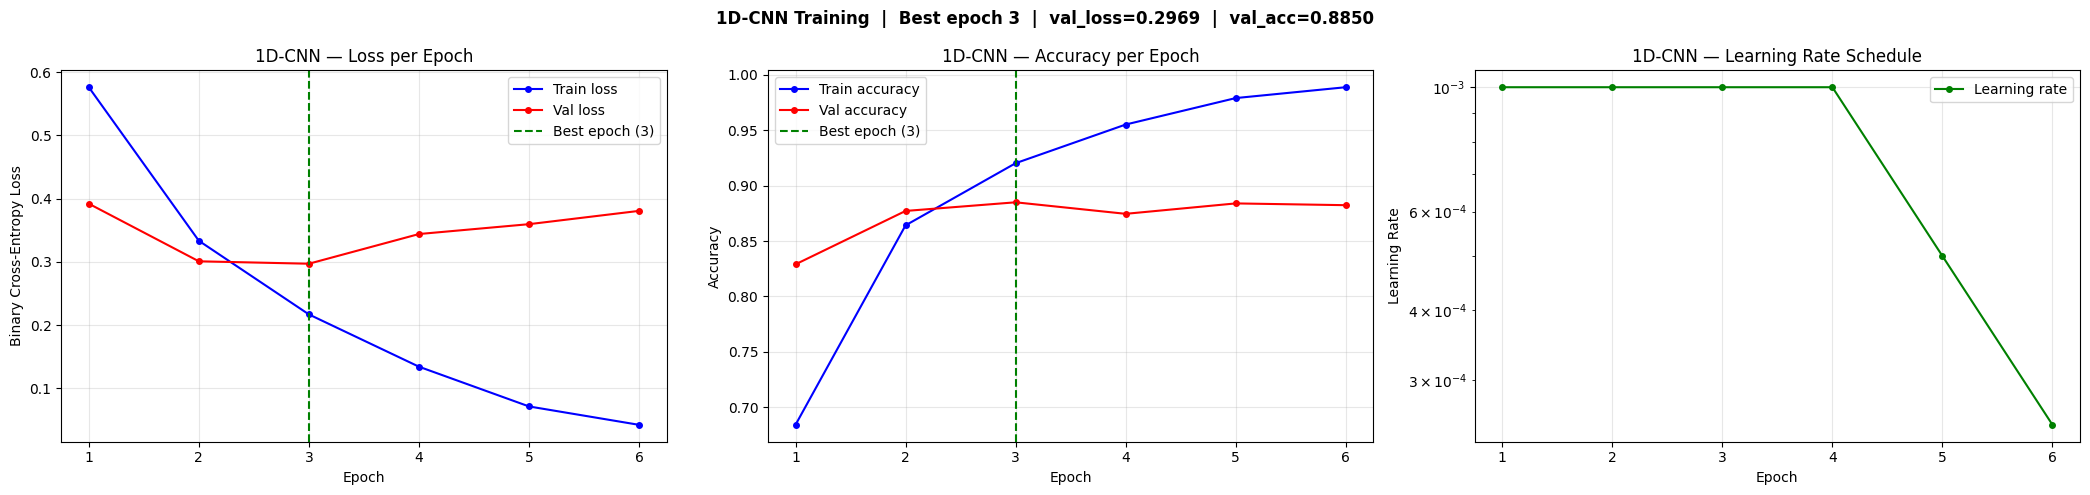

Training curves saved locally.


In [ ]:
# ── CELL 6 : Training Curves ─────────────────────────────────────────────────
# To reload and re-plot without retraining:
# with open(f"{DRIVE['history']}/cnn_history.json") as f:
#     history_data = json.load(f)

epochs = range(1, history_data['epochs_run'] + 1)
best_e = np.argmin(history_data['val_loss']) + 1
has_lr = len(history_data['lr']) > 0

n_plots = 3 if has_lr else 2
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))

# Loss
axes[0].plot(epochs, history_data['train_loss'], 'b-o',
             markersize=4, label='Train loss')
axes[0].plot(epochs, history_data['val_loss'],   'r-o',
             markersize=4, label='Val loss')
axes[0].axvline(best_e, color='green', linestyle='--',
                label=f'Best epoch ({best_e})')
axes[0].set_title('1D-CNN — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, history_data['train_accuracy'], 'b-o',
             markersize=4, label='Train accuracy')
axes[1].plot(epochs, history_data['val_accuracy'],   'r-o',
             markersize=4, label='Val accuracy')
axes[1].axvline(best_e, color='green', linestyle='--',
                label=f'Best epoch ({best_e})')
axes[1].set_title('1D-CNN — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning rate (shows ReduceLROnPlateau effect)
if has_lr:
    axes[2].plot(epochs, history_data['lr'], 'g-o',
                 markersize=4, label='Learning rate')
    axes[2].set_title('1D-CNN — Learning Rate Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_yscale('log')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

plt.suptitle(
    f"1D-CNN Training  |  Best epoch {best_e}  |  "
    f"val_loss={history_data['val_loss'][best_e-1]:.4f}  |  "
    f"val_acc={history_data['val_accuracy'][best_e-1]:.4f}",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/01_cnn_training_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved locally.")

In [ ]:
# ── CELL 7 : Validation Evaluation ───────────────────────────────────────────
val_probs = model.predict(X_val, batch_size=64, verbose=0).flatten()
val_preds = (val_probs >= 0.5).astype(int)

val_metrics = {
    'model'    : 'CNN_1D',
    'split'    : 'validation',
    'max_len'  : MAX_LEN,
    'accuracy' : float(accuracy_score(val_labels,  val_preds)),
    'precision': float(precision_score(val_labels, val_preds)),
    'recall'   : float(recall_score(val_labels,    val_preds)),
    'f1'       : float(f1_score(val_labels,        val_preds)),
    'auc'      : float(roc_auc_score(val_labels,   val_probs)),
}

print("── Validation Metrics ──────────────────────")
for k, v in val_metrics.items():
    if k not in ('model', 'split', 'max_len'):
        print(f"  {k:12s}: {v:.4f}")
print()
print(classification_report(
    val_labels, val_preds,
    target_names=['Negative', 'Positive']
))

# Save to Drive
fpr, tpr, _ = roc_curve(val_labels, val_probs)
roc_val = {
    'fpr': fpr.tolist(),
    'tpr': tpr.tolist(),
    'auc': val_metrics['auc']
}

np.save(f"{DRIVE['results']}/val_probs.npy", val_probs)
np.save(f"{DRIVE['results']}/val_preds.npy", val_preds)
with open(f"{DRIVE['results']}/val_metrics.json", 'w') as f:
    json.dump(val_metrics, f, indent=2)
with open(f"{DRIVE['results']}/roc_val.json", 'w') as f:
    json.dump(roc_val, f)
print("Val probs, preds, metrics, ROC saved to Drive.")

── Validation Metrics ──────────────────────
  accuracy    : 0.8850
  precision   : 0.8953
  recall      : 0.8720
  f1          : 0.8835
  auc         : 0.9545

              precision    recall  f1-score   support

    Negative       0.88      0.90      0.89      2500
    Positive       0.90      0.87      0.88      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.88      5000
weighted avg       0.89      0.89      0.88      5000

Val probs, preds, metrics, ROC saved to Drive.


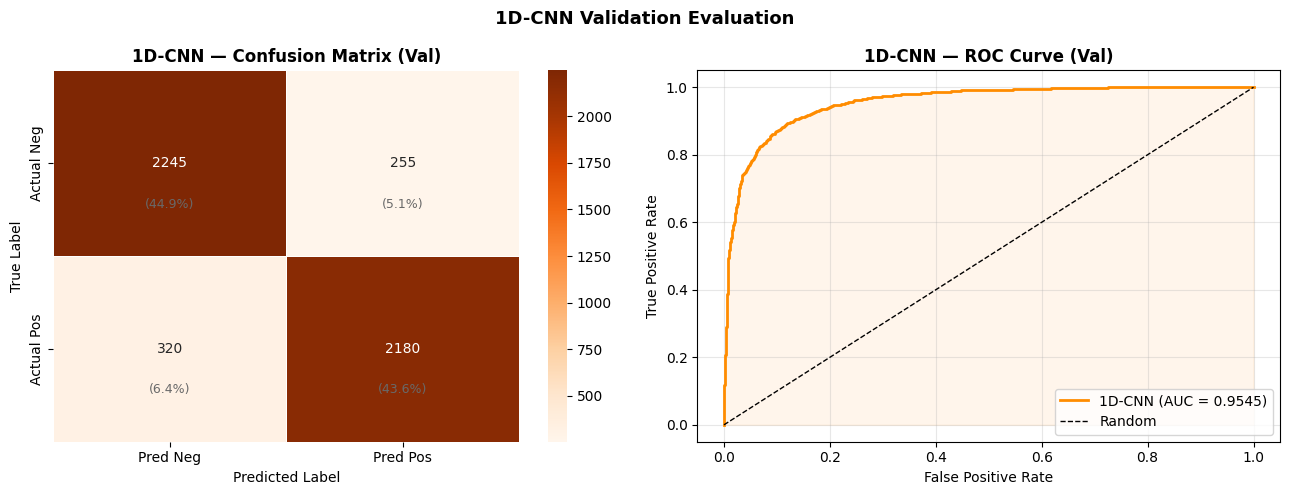

In [ ]:
# ── CELL 8 : Confusion Matrix + ROC — Validation ────────────────────────────
# To re-plot without retraining:
# val_probs = np.load(f"{DRIVE['results']}/val_probs.npy")
# val_preds = np.load(f"{DRIVE['results']}/val_preds.npy")
# with open(f"{DRIVE['results']}/roc_val.json") as f:
#     roc_val = json.load(f)

cm = confusion_matrix(val_labels, val_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
    xticklabels=['Pred Neg', 'Pred Pos'],
    yticklabels=['Actual Neg', 'Actual Pos'],
    linewidths=0.5
)
for i in range(2):
    for j in range(2):
        axes[0].text(
            j + 0.5, i + 0.72,
            f"({cm[i,j] / cm.sum() * 100:.1f}%)",
            ha='center', va='center',
            fontsize=9, color='dimgray'
        )
axes[0].set_title('1D-CNN — Confusion Matrix (Val)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(roc_val['fpr'], roc_val['tpr'],
             color='darkorange', lw=2,
             label=f"1D-CNN (AUC = {roc_val['auc']:.4f})")
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random')
axes[1].fill_between(roc_val['fpr'], roc_val['tpr'],
                     alpha=0.08, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('1D-CNN — ROC Curve (Val)', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.suptitle('1D-CNN Validation Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/02_cnn_val_cm_roc.png",
            dpi=150, bbox_inches='tight')
plt.show()

── TEST RESULTS ───────────────────────────
  accuracy    : 0.8827
  precision   : 0.8946
  recall      : 0.8676
  f1          : 0.8809
  auc         : 0.9515

              precision    recall  f1-score   support

    Negative       0.87      0.90      0.88     12500
    Positive       0.89      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



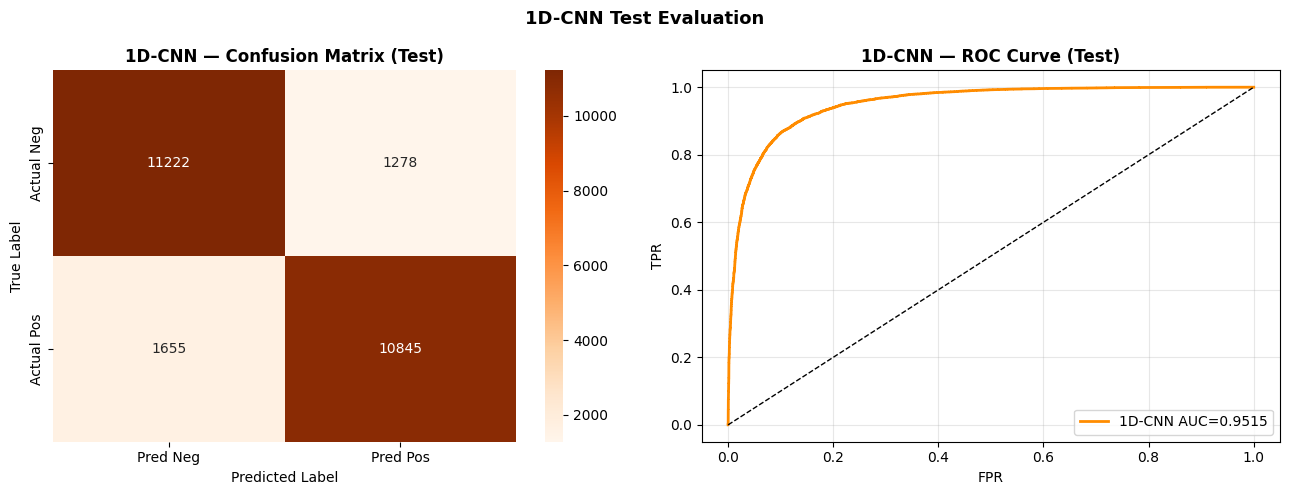

All test results saved to Drive.


In [ ]:
# ── CELL 9 : TEST SET EVALUATION ─────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ONLY RUN AFTER ALL FOUR MODELS ARE FULLY FINALIZED.            ║
# ║  The test set must not influence any further decisions.          ║
# ╚══════════════════════════════════════════════════════════════════╝

test_probs = model.predict(X_test, batch_size=64, verbose=0).flatten()
test_preds = (test_probs >= 0.5).astype(int)

test_metrics = {
    'model'    : 'CNN_1D',
    'split'    : 'test',
    'max_len'  : MAX_LEN,
    'accuracy' : float(accuracy_score(test_labels,  test_preds)),
    'precision': float(precision_score(test_labels, test_preds)),
    'recall'   : float(recall_score(test_labels,    test_preds)),
    'f1'       : float(f1_score(test_labels,        test_preds)),
    'auc'      : float(roc_auc_score(test_labels,   test_probs)),
}

print("── TEST RESULTS ───────────────────────────")
for k, v in test_metrics.items():
    if k not in ('model', 'split', 'max_len'):
        print(f"  {k:12s}: {v:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=['Negative', 'Positive']
))

# Save to Drive
fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
roc_test = {
    'fpr': fpr_t.tolist(),
    'tpr': tpr_t.tolist(),
    'auc': test_metrics['auc']
}

np.save(f"{DRIVE['results']}/test_probs.npy", test_probs)
np.save(f"{DRIVE['results']}/test_preds.npy", test_preds)
with open(f"{DRIVE['results']}/test_metrics.json", 'w') as f:
    json.dump(test_metrics, f, indent=2)
with open(f"{DRIVE['results']}/roc_test.json", 'w') as f:
    json.dump(roc_test, f)

# Test confusion matrix + ROC
cm_t = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm_t, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
    xticklabels=['Pred Neg', 'Pred Pos'],
    yticklabels=['Actual Neg', 'Actual Pos']
)
axes[0].set_title('1D-CNN — Confusion Matrix (Test)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(fpr_t, tpr_t, color='darkorange', lw=2,
             label=f"1D-CNN AUC={test_metrics['auc']:.4f}")
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('1D-CNN — ROC Curve (Test)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('1D-CNN Test Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/03_cnn_test_cm_roc.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("All test results saved to Drive.")

Correct : 22,067  (88.3%)
Wrong   : 2,933   (11.7%)


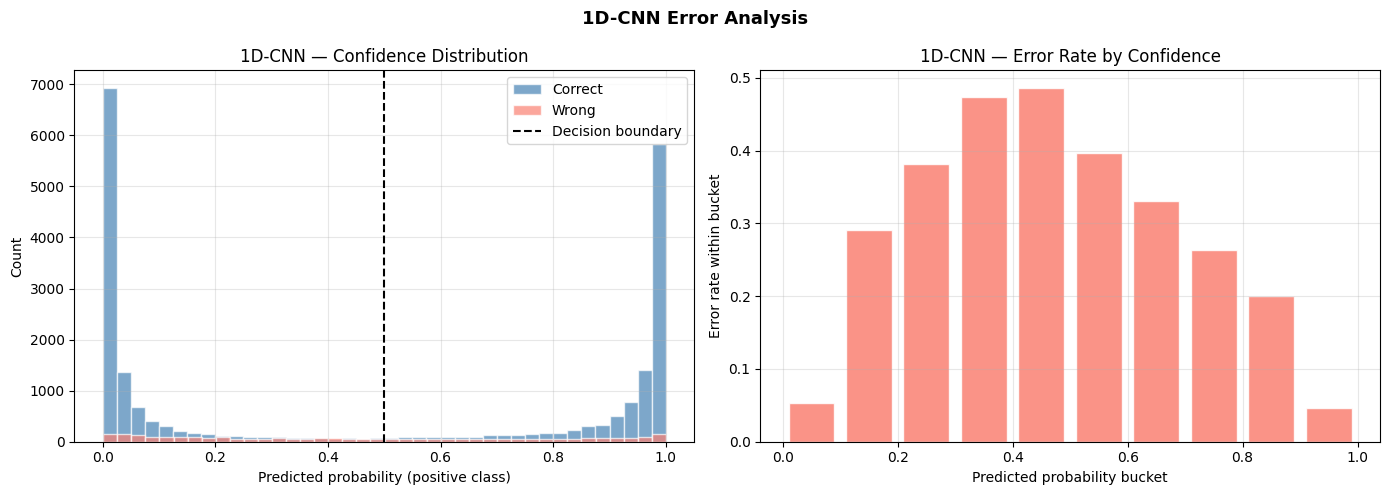


── 10 Misclassified Examples ────────────────────────────────────────

  [16] True=NEG  Pred=POS  Conf=0.699
  At the bottom end of the apocalypse movie scale is this piece of pish called 'The Final Executioner'.. at least where I come from. A bloke is trained by an ex-cop to seek vengeance on those that killed his woman and friends in cold blood.. and that's...

  [17] True=NEG  Pred=POS  Conf=0.895
  Earth has been destroyed in a nuclear holocaust. Well, parts of the Earth, because somewhere in Italy, a band of purebred survivors--those without radioactive contamination--are holed up in a massive mansion surrounded by lush grounds, waiting for th...

  [19] True=NEG  Pred=POS  Conf=0.886
  New York family is the last in their neighborhood to get a television set, which nearly ruins David Niven's marriage to Mitzi Gaynor. Bedroom comedy that rarely ventures into the bedroom(and nothing sexy happens there anyway). Gaynor as an actress ha...

  [44] True=NEG  Pred=POS  Conf=0.967
  Thi

In [ ]:
# ── CELL 10 : Error Analysis ──────────────────────────────────────────────────
# To reload without retraining:
# test_probs = np.load(f"{DRIVE['results']}/test_probs.npy")
# test_preds = np.load(f"{DRIVE['results']}/test_preds.npy")

wrong = np.where(test_preds != test_labels)[0]
right = np.where(test_preds == test_labels)[0]

print(f"Correct : {len(right):,}  ({len(right)/len(test_labels)*100:.1f}%)")
print(f"Wrong   : {len(wrong):,}   ({len(wrong)/len(test_labels)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence distribution
axes[0].hist(test_probs[right], bins=40, color='steelblue',
             alpha=0.7, label='Correct', edgecolor='white')
axes[0].hist(test_probs[wrong], bins=40, color='salmon',
             alpha=0.7, label='Wrong',   edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--',
                label='Decision boundary')
axes[0].set_xlabel('Predicted probability (positive class)')
axes[0].set_ylabel('Count')
axes[0].set_title('1D-CNN — Confidence Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Error rate by confidence bucket
buckets = np.linspace(0, 1, 11)
mids, rates = [], []
for lo, hi in zip(buckets[:-1], buckets[1:]):
    mask = (test_probs >= lo) & (test_probs < hi)
    if mask.sum() > 0:
        mids.append((lo + hi) / 2)
        rates.append((test_preds[mask] != test_labels[mask]).mean())

axes[1].bar(mids, rates, width=0.08, color='salmon',
            edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Predicted probability bucket')
axes[1].set_ylabel('Error rate within bucket')
axes[1].set_title('1D-CNN — Error Rate by Confidence')
axes[1].grid(alpha=0.3)

plt.suptitle('1D-CNN Error Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/04_cnn_error_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Print 10 misclassified examples
print("\n── 10 Misclassified Examples ────────────────────────────────────────")
for idx in wrong[:10]:
    true = 'POS' if test_labels[idx] == 1 else 'NEG'
    pred = 'POS' if test_preds[idx]  == 1 else 'NEG'
    conf = test_probs[idx] if test_preds[idx] == 1 else 1 - test_probs[idx]
    print(f"\n  [{idx}] True={true}  Pred={pred}  Conf={conf:.3f}")
    print(f"  {test_texts[idx][:250]}...")